# Data Understanding
## Analisis Parameter Polutan Atmosfer Desa Sidojangkung

Notebook ini digunakan untuk melakukan tahap **Data Understanding** pada proyek Proyek Sains Data (PSD).

Wilayah penelitian:
- Desa: Sidojangkung
- Kecamatan: Menganti
- Kabupaten: Gresik
- Provinsi: Jawa Timur

Sumber data parameter atmosfer:
- Copernicus Sentinel-5P / TROPOMI Level-2

Parameter yang dianalisis:
- NO₂ (Nitrogen Dioxide)
- CO (Carbon Monoxide)
- O₃ (Ozone)
- SO₂ (Sulfur Dioxide)

Periode pengamatan:
**1 September 2025 – 30 Agustus 2026**

Data telah diagregasi secara harian menggunakan batas wilayah Desa Sidojangkung dalam format GeoJSON.

## 1. Tujuan Data Understanding

Tahap Data Understanding dilakukan untuk memahami struktur, karakteristik, kelengkapan, dan kualitas dataset sebelum memasuki tahap Data Preparation.

Eksplorasi yang dilakukan meliputi:

1. Memahami struktur dataset.
2. Mendeskripsikan setiap fitur.
3. Menghitung statistik deskriptif.
4. Memeriksa missing value.
5. Mengidentifikasi nilai yang tidak biasa.
6. Menganalisis perubahan parameter polutan berdasarkan waktu.

In [44]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset kualitas udara

DATA_PATH = "../data/processed/sidojangkung_air_quality_daily.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,date,no2_mean,no2_min,no2_max,no2_stdev,no2_sample_count,no2_nodata_count,co_mean,co_min,co_max,...,o3_max,o3_stdev,o3_sample_count,o3_nodata_count,so2_mean,so2_min,so2_max,so2_stdev,so2_sample_count,so2_nodata_count
0,2025-09-01,0.000028,0.000028,0.000028,8.421102e-08,2,0,0.024130,0.023843,0.024417,...,0.116017,0.000349,2,0,-0.000008,-0.000102,0.000086,0.000094,2,0
1,2025-09-02,0.000026,0.000026,0.000026,0.000000e+00,2,0,0.023826,0.022839,0.024813,...,0.114800,0.000000,2,0,-0.000126,-0.000126,-0.000126,0.000000,2,0
2,2025-09-03,0.000025,0.000025,0.000025,0.000000e+00,2,0,0.023421,0.022760,0.024081,...,0.113417,0.000000,2,0,0.000005,0.000005,0.000005,0.000000,2,0
3,2025-09-04,0.000029,0.000029,0.000029,0.000000e+00,2,0,NaN,NaN,NaN,...,0.114204,0.000000,2,0,0.000512,0.000512,0.000512,0.000000,2,0
4,2025-09-05,NaN,NaN,NaN,NaN,2,2,0.033698,0.033698,0.033698,...,0.113721,0.000000,2,0,-0.000386,-0.000386,-0.000386,0.000000,2,0


In [45]:
# Ukuran dataset

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris : 364
Jumlah kolom: 25


In [46]:
# Informasi dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              364 non-null    str    
 1   no2_mean          170 non-null    float64
 2   no2_min           170 non-null    float64
 3   no2_max           170 non-null    float64
 4   no2_stdev         170 non-null    float64
 5   no2_sample_count  364 non-null    int64  
 6   no2_nodata_count  364 non-null    int64  
 7   co_mean           220 non-null    float64
 8   co_min            220 non-null    float64
 9   co_max            220 non-null    float64
 10  co_stdev          220 non-null    float64
 11  co_sample_count   364 non-null    int64  
 12  co_nodata_count   364 non-null    int64  
 13  o3_mean           360 non-null    float64
 14  o3_min            360 non-null    float64
 15  o3_max            360 non-null    float64
 16  o3_stdev          360 non-null    float64
 17  o3_sampl

In [47]:
# Konversi kolom tanggal

df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              364 non-null    datetime64[us]
 1   no2_mean          170 non-null    float64       
 2   no2_min           170 non-null    float64       
 3   no2_max           170 non-null    float64       
 4   no2_stdev         170 non-null    float64       
 5   no2_sample_count  364 non-null    int64         
 6   no2_nodata_count  364 non-null    int64         
 7   co_mean           220 non-null    float64       
 8   co_min            220 non-null    float64       
 9   co_max            220 non-null    float64       
 10  co_stdev          220 non-null    float64       
 11  co_sample_count   364 non-null    int64         
 12  co_nodata_count   364 non-null    int64         
 13  o3_mean           360 non-null    float64       
 14  o3_min            360 non-null    flo

In [48]:
# Periode dataset

print("Tanggal awal :", df["date"].min().date())
print("Tanggal akhir:", df["date"].max().date())

Tanggal awal : 2025-09-01
Tanggal akhir: 2026-08-30


In [49]:
# Daftar fitur

for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

01. date
02. no2_mean
03. no2_min
04. no2_max
05. no2_stdev
06. no2_sample_count
07. no2_nodata_count
08. co_mean
09. co_min
10. co_max
11. co_stdev
12. co_sample_count
13. co_nodata_count
14. o3_mean
15. o3_min
16. o3_max
17. o3_stdev
18. o3_sample_count
19. o3_nodata_count
20. so2_mean
21. so2_min
22. so2_max
23. so2_stdev
24. so2_sample_count
25. so2_nodata_count


## 2. Deskripsi Dataset

Dataset terdiri atas data harian parameter atmosfer yang diperoleh dari Sentinel-5P/TROPOMI untuk wilayah Desa Sidojangkung.

Setiap baris merepresentasikan satu interval pengamatan harian. Dataset mencakup nilai statistik minimum, maksimum, rata-rata, dan standar deviasi untuk masing-masing parameter, serta informasi jumlah sampel dan jumlah data yang tidak tersedia.

In [50]:
feature_description = pd.DataFrame({
    "feature": [
        "date",
        "no2_mean", "no2_min", "no2_max", "no2_stdev",
        "no2_sample_count", "no2_nodata_count",
        "co_mean", "co_min", "co_max", "co_stdev",
        "co_sample_count", "co_nodata_count",
        "o3_mean", "o3_min", "o3_max", "o3_stdev",
        "o3_sample_count", "o3_nodata_count",
        "so2_mean", "so2_min", "so2_max", "so2_stdev",
        "so2_sample_count", "so2_nodata_count"
    ],
    "description": [
        "Tanggal pengamatan",

        "Rata-rata NO₂",
        "Nilai minimum NO₂",
        "Nilai maksimum NO₂",
        "Standar deviasi NO₂",
        "Jumlah sampel/pixel NO₂ yang digunakan",
        "Jumlah sampel/pixel NO₂ tanpa data",

        "Rata-rata CO",
        "Nilai minimum CO",
        "Nilai maksimum CO",
        "Standar deviasi CO",
        "Jumlah sampel/pixel CO yang digunakan",
        "Jumlah sampel/pixel CO tanpa data",

        "Rata-rata O₃",
        "Nilai minimum O₃",
        "Nilai maksimum O₃",
        "Standar deviasi O₃",
        "Jumlah sampel/pixel O₃ yang digunakan",
        "Jumlah sampel/pixel O₃ tanpa data",

        "Rata-rata SO₂",
        "Nilai minimum SO₂",
        "Nilai maksimum SO₂",
        "Standar deviasi SO₂",
        "Jumlah sampel/pixel SO₂ yang digunakan",
        "Jumlah sampel/pixel SO₂ tanpa data"
    ]
})

feature_description

,feature,description
0,date,Tanggal pengamatan
1,no2_mean,Rata-rata NO₂
2,no2_min,Nilai minimum NO₂
3,no2_max,Nilai maksimum NO₂
4,no2_stdev,Standar deviasi NO₂
5,no2_sample_count,Jumlah sampel/pixel NO₂ yang digunakan
6,no2_nodata_count,Jumlah sampel/pixel NO₂ tanpa data
7,co_mean,Rata-rata CO
8,co_min,Nilai minimum CO
9,co_max,Nilai maksimum CO


## 3. Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat karakteristik dasar masing-masing parameter polutan yang diamati.

Statistik yang dihitung meliputi:
- jumlah data valid;
- jumlah missing value;
- nilai minimum;
- nilai maksimum;
- rata-rata;
- median;
- standar deviasi.

In [51]:
# Statistik deskriptif masing-masing parameter

pollutants = {
    "NO₂": "no2_mean",
    "CO": "co_mean",
    "O₃": "o3_mean",
    "SO₂": "so2_mean"
}

stats = []

for pollutant, column in pollutants.items():
    series = df[column]

    stats.append({
        "Polutan": pollutant,
        "Data Valid": series.notna().sum(),
        "Missing": series.isna().sum(),
        "Minimum": series.min(),
        "Mean": series.mean(),
        "Median": series.median(),
        "Std": series.std(),
        "Maximum": series.max()
    })

stats_df = pd.DataFrame(stats)

stats_df

,Polutan,Data Valid,Missing,Minimum,Mean,Median,Std,Maximum
0,NO₂,170,194,0.000014,0.000047,0.000042,0.000020,0.000098
1,CO,220,144,0.020222,0.029561,0.029231,0.003870,0.045216
2,O₃,360,4,0.109509,0.115803,0.115565,0.002468,0.122766
3,SO₂,218,146,-0.001271,0.000077,0.000075,0.000316,0.001428


In [52]:
# Format tampilan angka

stats_display = stats_df.copy()

for column in [
    "Minimum",
    "Mean",
    "Median",
    "Std",
    "Maximum"
]:
    stats_display[column] = stats_display[column].map(
        lambda x: f"{x:.8f}" if pd.notna(x) else "-"
    )

stats_display

,Polutan,Data Valid,Missing,Minimum,Mean,Median,Std,Maximum
0,NO₂,170,194,0.00001351,0.00004653,0.00004225,0.00001990,0.00009766
1,CO,220,144,0.02022203,0.02956117,0.02923118,0.00386983,0.04521559
2,O₃,360,4,0.10950902,0.11580302,0.11556520,0.00246795,0.12276649
3,SO₂,218,146,-0.00127074,0.00007733,0.00007520,0.00031595,0.00142838


## 4. Analisis Missing Value

Missing value menunjukkan interval waktu ketika tidak terdapat nilai valid yang dapat digunakan untuk parameter tertentu.

Missing value tidak dianggap sebagai nilai nol karena tidak adanya observasi berbeda dengan nilai pengukuran sebesar nol.

In [53]:
# Analisis missing value

missing_df = pd.DataFrame({
    "Polutan": list(pollutants.keys()),
    "Missing": [
        df[column].isna().sum()
        for column in pollutants.values()
    ],
    "Valid": [
        df[column].notna().sum()
        for column in pollutants.values()
    ]
})

missing_df["Coverage (%)"] = (
    missing_df["Valid"] / len(df) * 100
).round(2)

missing_df["Missing (%)"] = (
    missing_df["Missing"] / len(df) * 100
).round(2)

missing_df

,Polutan,Missing,Valid,Coverage (%),Missing (%)
0,NO₂,194,170,46.70,53.30
1,CO,144,220,60.44,39.56
2,O₃,4,360,98.90,1.10
3,SO₂,146,218,59.89,40.11


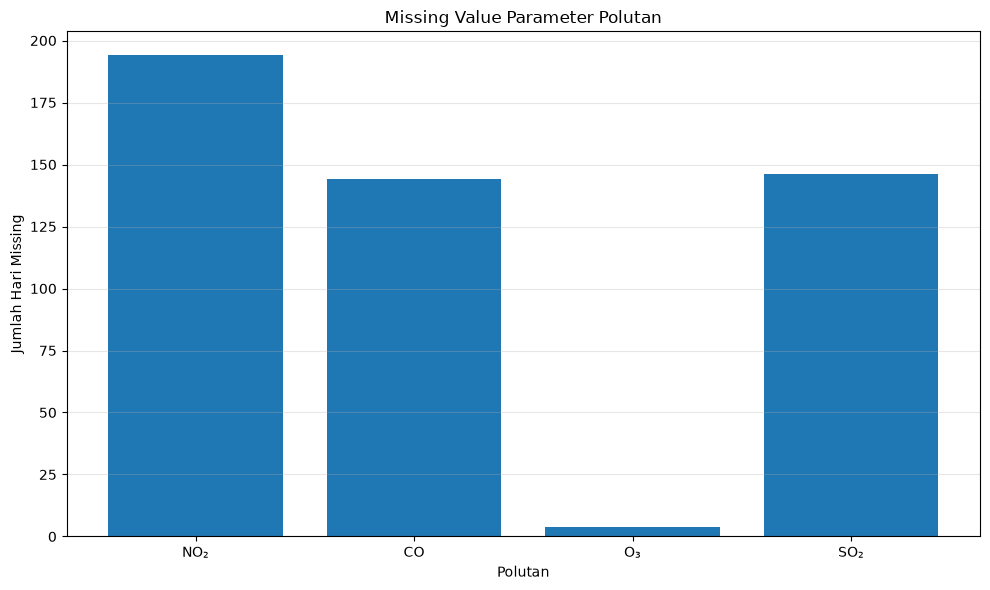

In [54]:
plt.figure(figsize=(10, 6))

plt.bar(
    missing_df["Polutan"],
    missing_df["Missing"]
)

plt.title("Missing Value Parameter Polutan")
plt.xlabel("Polutan")
plt.ylabel("Jumlah Hari Missing")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 5. Pemeriksaan Nilai Tidak Biasa

Pada tahap ini dilakukan pemeriksaan awal terhadap nilai yang berada di luar pola umum data.

Perhatian khusus diberikan pada parameter SO₂ karena pada eksplorasi awal ditemukan nilai negatif.

In [55]:
# Nilai minimum dan maksimum masing-masing parameter

for pollutant, column in pollutants.items():
    print(
        f"{pollutant}: "
        f"min = {df[column].min()}, "
        f"max = {df[column].max()}"
    )

NO₂: min = 1.3505949937098194e-05, max = 9.7659467428457e-05
CO: min = 0.020222034305334, max = 0.0452155917882919
O₃: min = 0.1095090210437774, max = 0.1227664873003959
SO₂: min = -0.001270740525797, max = 0.0014283846830949


In [56]:
# 10 nilai SO₂ paling rendah

df[
    ["date", "so2_mean"]
].sort_values(
    "so2_mean",
    ascending=True
).head(10)

,date,so2_mean
303,2026-07-01,-0.001271
319,2026-07-17,-0.000987
281,2026-06-09,-0.000972
253,2026-05-12,-0.000647
313,2026-07-11,-0.000627
314,2026-07-12,-0.000621
346,2026-08-13,-0.000551
207,2026-03-27,-0.000466
4,2025-09-05,-0.000386
288,2026-06-16,-0.000380


In [57]:
# 10 nilai SO₂ paling tinggi

df[
    ["date", "so2_mean"]
].sort_values(
    "so2_mean",
    ascending=False
).head(10)

,date,so2_mean
26,2025-09-27,0.001428
47,2025-10-18,0.001299
342,2026-08-09,0.000981
361,2026-08-28,0.000765
338,2026-08-05,0.000760
291,2026-06-19,0.000708
353,2026-08-20,0.000623
119,2025-12-29,0.000592
278,2026-06-06,0.000574
298,2026-06-26,0.000569


## 6. Analisis Rata-rata Bulanan

Analisis rata-rata bulanan digunakan untuk melihat perubahan parameter polutan pada skala waktu yang lebih panjang.

Agregasi bulanan dilakukan tanpa mengisi missing value. Nilai yang tidak tersedia tetap diperlakukan sebagai missing dan tidak digunakan dalam perhitungan rata-rata.

In [58]:
# Pastikan tanggal menjadi index

df_monthly = (
    df.set_index("date")
      .resample("MS")[
          [
              "no2_mean",
              "co_mean",
              "o3_mean",
              "so2_mean"
          ]
      ]
      .mean()
)

df_monthly

,no2_mean,co_mean,o3_mean,so2_mean
date,,,,
2025-09-01,0.000040,0.029711,0.114380,0.000125
2025-10-01,0.000054,0.032990,0.116523,0.000084
2025-11-01,0.000041,0.028576,0.115483,0.000065
2025-12-01,0.000036,0.027718,0.114927,0.000161
2026-01-01,0.000028,0.028105,0.113041,0.000122
2026-02-01,0.000023,0.028034,0.113393,0.000074
2026-03-01,0.000027,0.029861,0.114772,-0.000020
2026-04-01,0.000047,0.028042,0.117085,0.000087
2026-05-01,0.000047,0.029571,0.116397,0.000044


In [59]:
monthly_display = df_monthly.copy()

monthly_display.index = monthly_display.index.strftime("%Y-%m")

monthly_display

,no2_mean,co_mean,o3_mean,so2_mean
date,,,,
2025-09,0.000040,0.029711,0.114380,0.000125
2025-10,0.000054,0.032990,0.116523,0.000084
2025-11,0.000041,0.028576,0.115483,0.000065
2025-12,0.000036,0.027718,0.114927,0.000161
2026-01,0.000028,0.028105,0.113041,0.000122
2026-02,0.000023,0.028034,0.113393,0.000074
2026-03,0.000027,0.029861,0.114772,-0.000020
2026-04,0.000047,0.028042,0.117085,0.000087
2026-05,0.000047,0.029571,0.116397,0.000044


### Interpretasi Awal Rata-rata Bulanan

Rata-rata bulanan digunakan untuk mengamati perubahan umum setiap parameter sepanjang periode penelitian.

Interpretasi dilakukan dengan membandingkan perubahan nilai antarbulan dan tidak digunakan untuk menyimpulkan hubungan sebab-akibat dengan faktor eksternal.

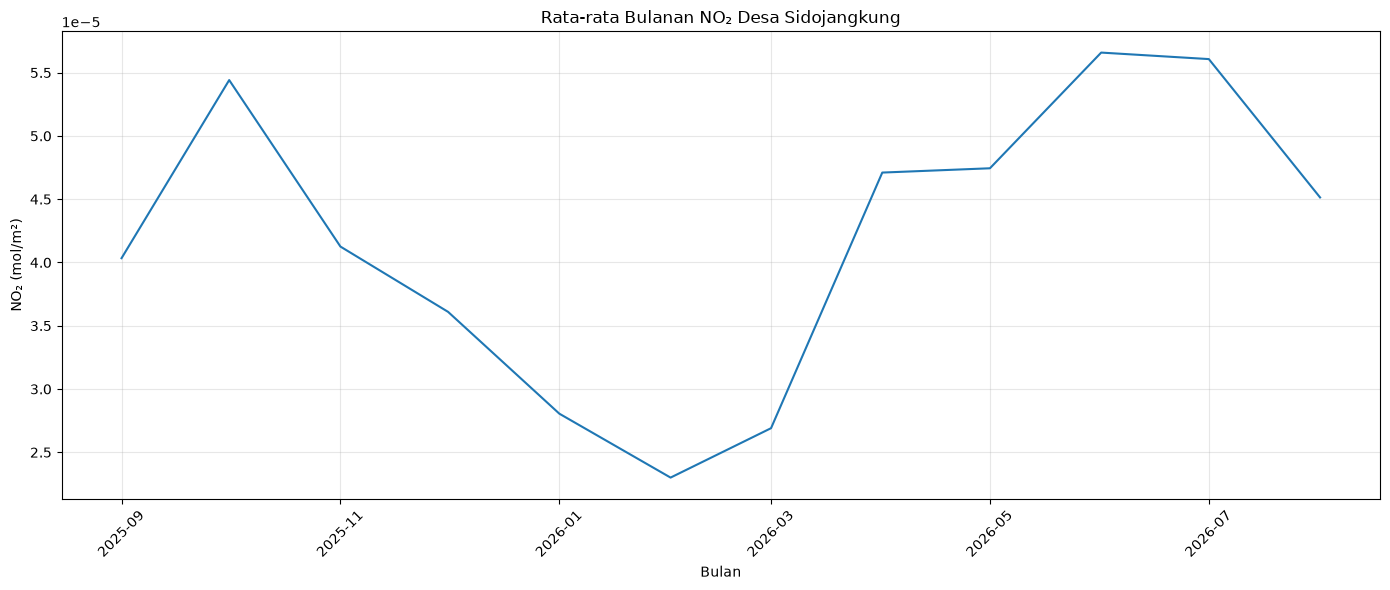

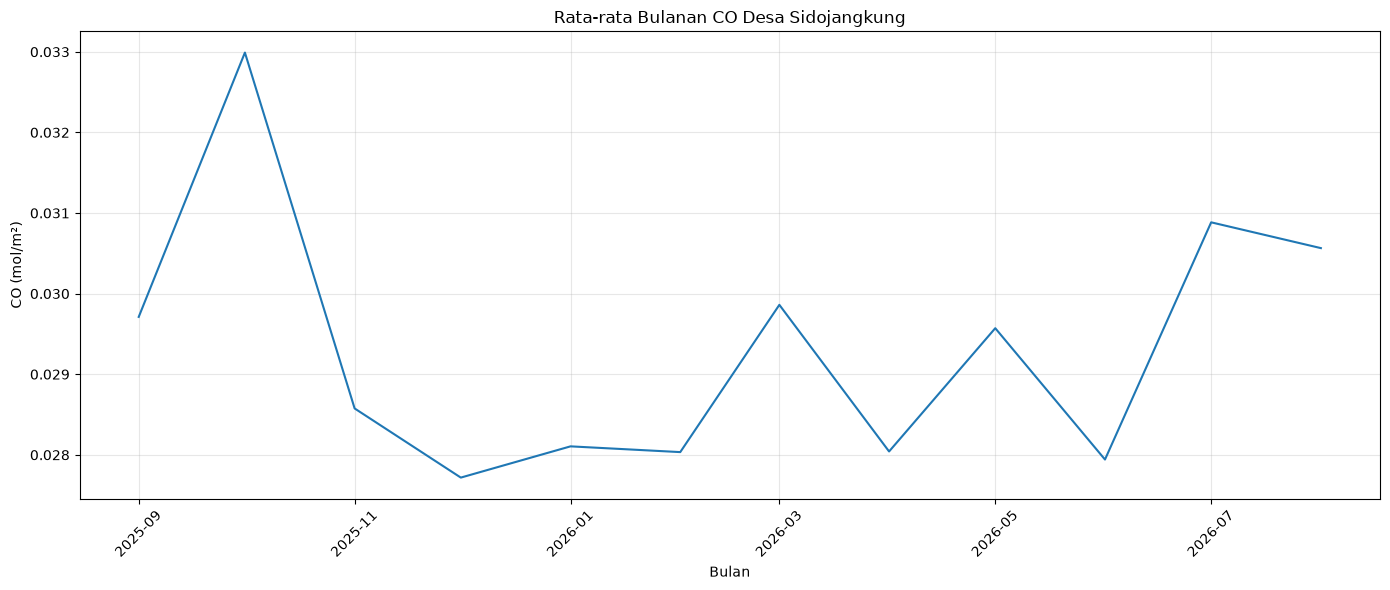

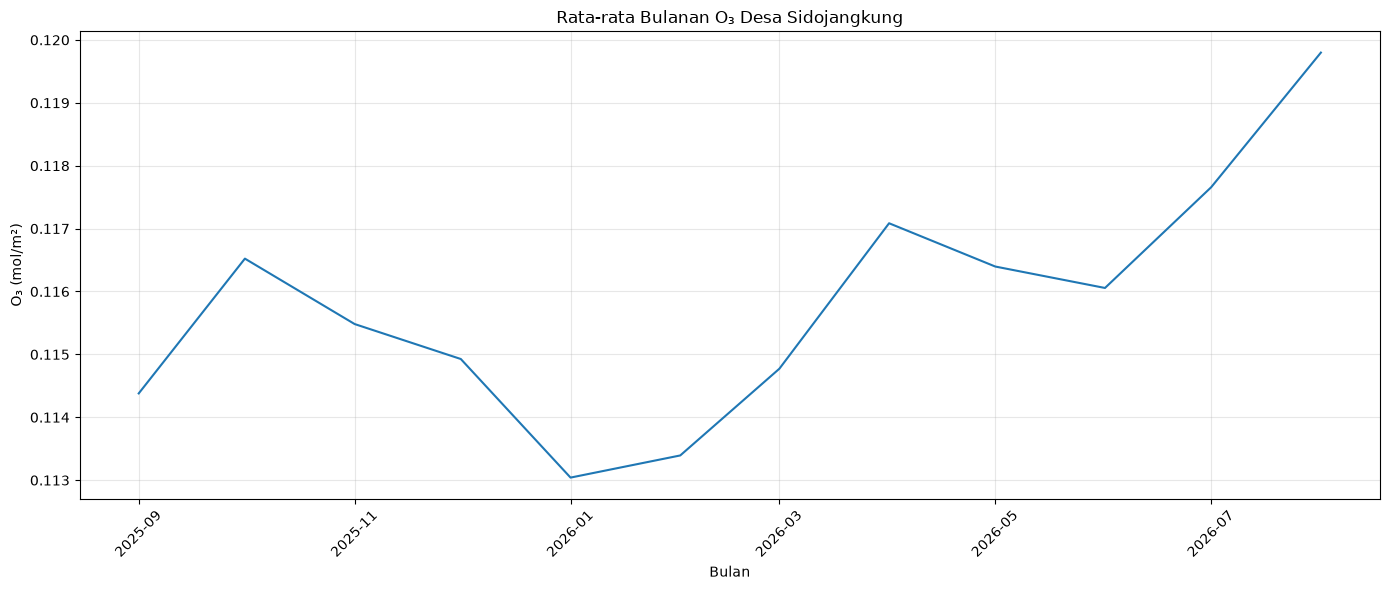

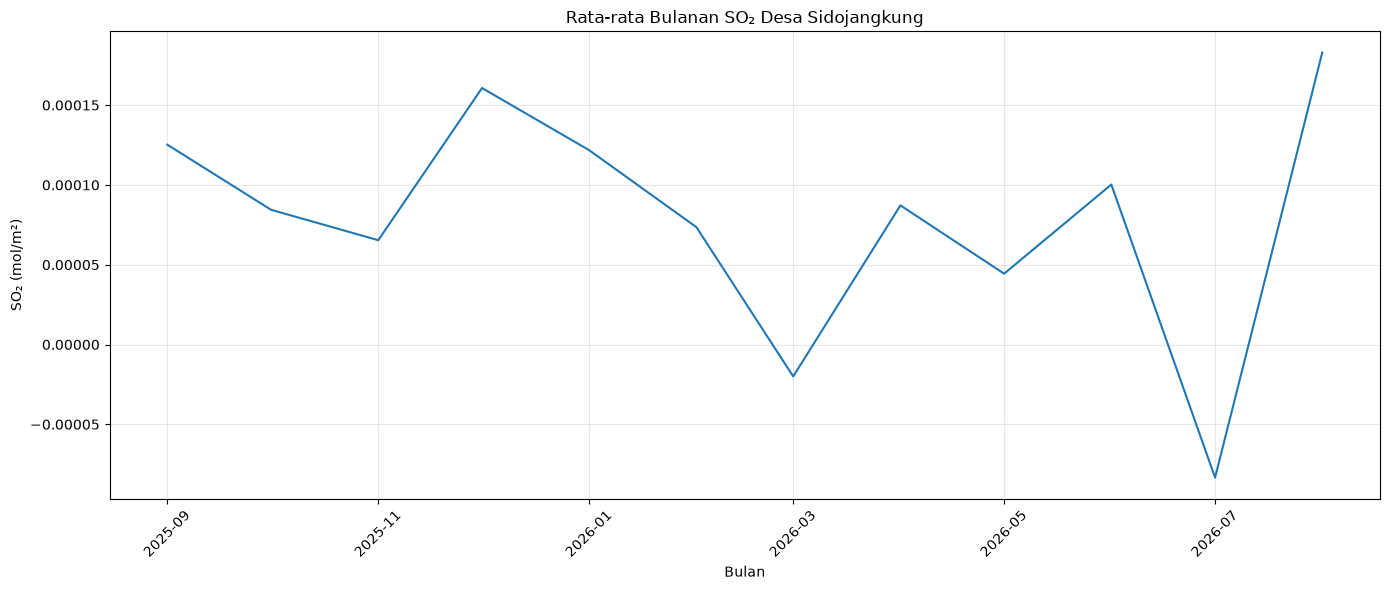

In [60]:
for label, column in pollutants.items():

    plt.figure(figsize=(14, 6))

    plt.plot(
        df_monthly.index,
        df_monthly[column]
    )

    plt.title(
        f"Rata-rata Bulanan {label} "
        "Desa Sidojangkung"
    )

    plt.xlabel("Bulan")
    plt.ylabel(f"{label} (mol/m²)")

    plt.xticks(rotation=45)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 7. Visualisasi Time Series

Time series digunakan untuk melihat perubahan nilai parameter polutan dari hari ke hari selama periode pengamatan.

Nilai missing tidak diubah menjadi nol sehingga gap pada grafik tetap menunjukkan tidak tersedianya observasi.

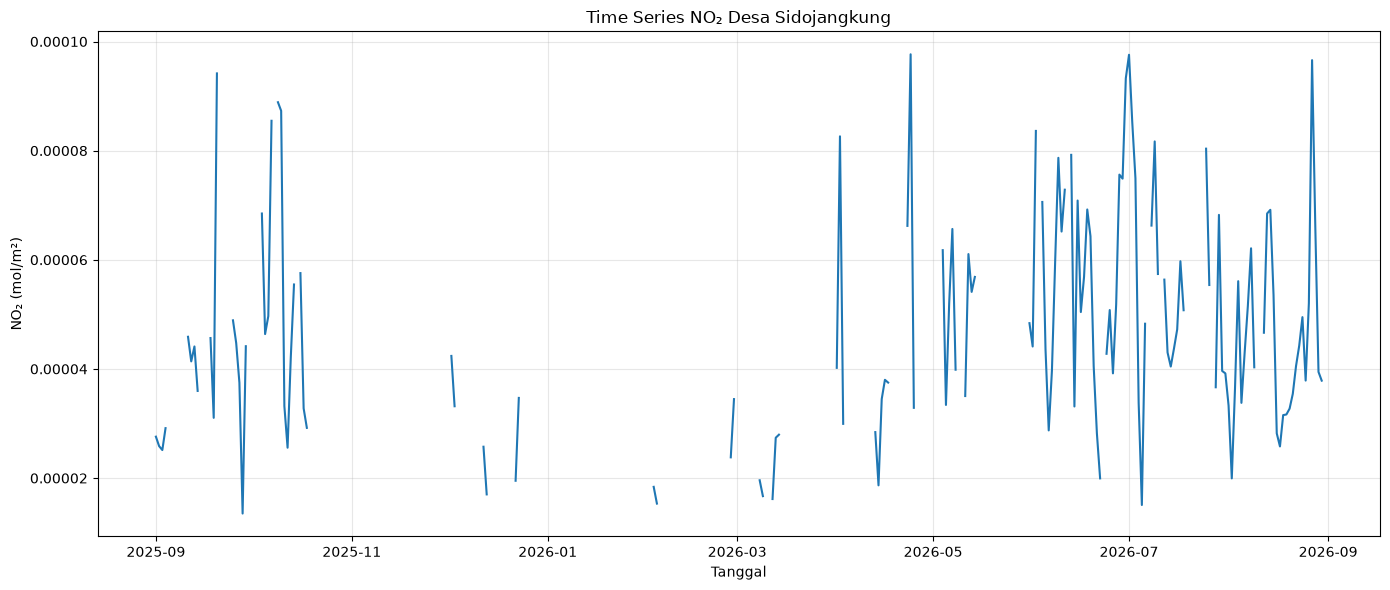

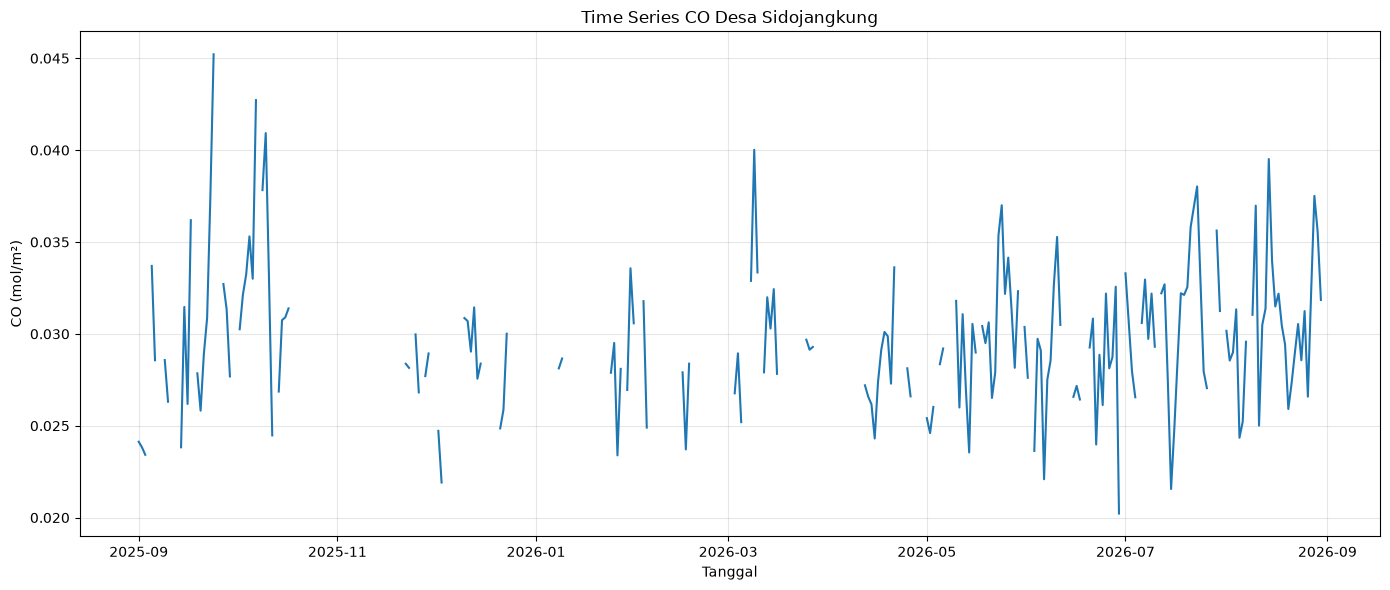

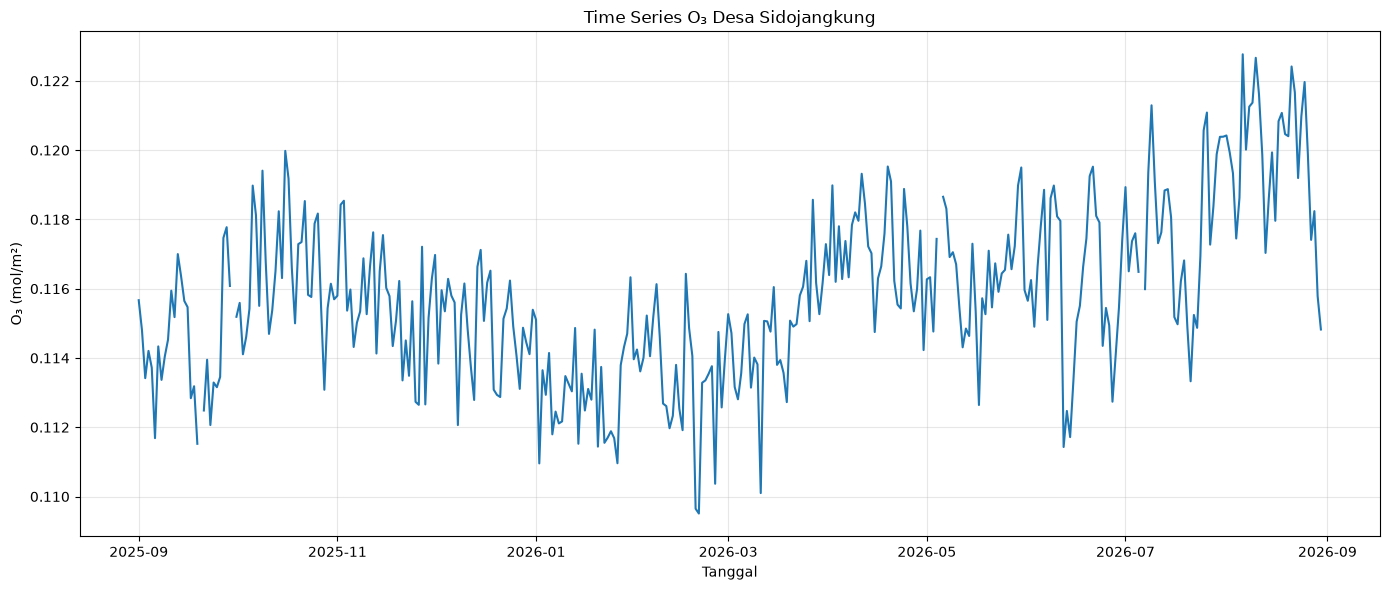

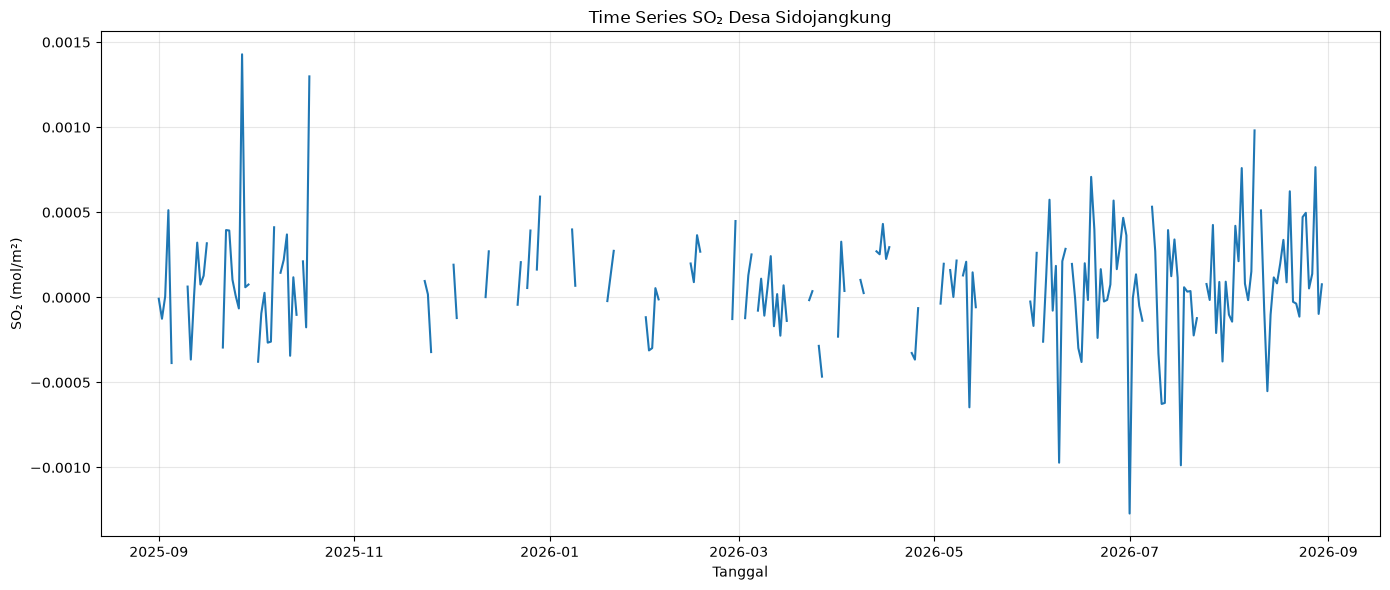

In [61]:
for label, column in pollutants.items():

    plt.figure(figsize=(14, 6))

    plt.plot(
        df["date"],
        df[column]
    )

    plt.title(
        f"Time Series {label} "
        "Desa Sidojangkung"
    )

    plt.xlabel("Tanggal")
    plt.ylabel(f"{label} (mol/m²)")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 8. Kelengkapan Data Berdasarkan Bulan

Selain menghitung jumlah missing secara keseluruhan, kelengkapan data diperiksa berdasarkan bulan untuk mengetahui apakah terdapat periode tertentu dengan jumlah observasi yang lebih sedikit.

In [62]:
monthly_coverage = {}

for pollutant, column in pollutants.items():

    coverage = (
        df.set_index("date")[column]
          .resample("MS")
          .apply(lambda x: x.notna().mean() * 100)
    )

    monthly_coverage[pollutant] = coverage

monthly_coverage_df = pd.DataFrame(
    monthly_coverage
)

monthly_coverage_df.index = (
    monthly_coverage_df.index.strftime("%Y-%m")
)

monthly_coverage_df.round(2)

,NO₂,CO,O₃,SO₂
date,,,,
2025-09,56.67,70.00,93.33,76.67
2025-10,48.39,54.84,100.00,54.84
2025-11,10.00,23.33,100.00,20.00
2025-12,35.48,48.39,100.00,45.16
2026-01,16.13,45.16,100.00,35.48
2026-02,14.29,28.57,100.00,46.43
2026-03,29.03,54.84,100.00,58.06
2026-04,46.67,53.33,100.00,53.33
2026-05,41.94,83.87,96.77,51.61


## 9. Temuan Data Understanding

Berdasarkan hasil eksplorasi dataset, diperoleh beberapa temuan utama:

1. Kelengkapan data berbeda antarparameter polutan. O₃ memiliki coverage paling tinggi sebesar 98,90%, sedangkan NO₂ memiliki coverage paling rendah sebesar 46,70%.

2. NO₂, CO, dan SO₂ memiliki missing value dalam jumlah cukup besar, sedangkan O₃ hanya memiliki sedikit missing value.

3. Ditemukan nilai negatif pada parameter SO₂. Nilai tersebut dicatat sebagai karakteristik data yang perlu diperiksa lebih lanjut pada tahap Data Preparation dan tidak langsung diubah pada tahap Data Understanding.

4. Nilai masing-masing parameter menunjukkan karakteristik temporal yang berbeda berdasarkan hasil analisis time series dan rata-rata bulanan.

5. Karena data berasal dari Sentinel-5P/TROPOMI, hasil pengamatan merepresentasikan parameter atmosfer berbasis satelit dan tidak dapat langsung disamakan dengan pengukuran kualitas udara permukaan dari stasiun pemantauan.

6. Missing value dan nilai yang tidak biasa akan menjadi perhatian pada tahap Data Preparation, khususnya dalam proses cleaning dan pemeriksaan outlier.

## 10. Kesimpulan

Data Understanding berhasil dilakukan terhadap dataset parameter atmosfer Desa Sidojangkung, Kecamatan Menganti, Kabupaten Gresik, dengan periode pengamatan 1 September 2025 sampai 30 Agustus 2026.

Dataset terdiri dari empat parameter, yaitu NO₂, CO, O₃, dan SO₂. Hasil eksplorasi menunjukkan bahwa tingkat kelengkapan data berbeda antarparameter. O₃ memiliki coverage paling tinggi, sedangkan NO₂ memiliki coverage paling rendah.

Eksplorasi juga menemukan missing value pada beberapa parameter serta nilai negatif pada SO₂. Temuan tersebut dipertahankan pada tahap Data Understanding agar karakteristik data asli tetap terlihat dan dapat ditangani secara tepat pada tahap Data Preparation.

Analisis statistik, rata-rata bulanan, dan time series menunjukkan bahwa masing-masing parameter memiliki pola temporal yang berbeda. Hasil ini menjadi dasar untuk tahap berikutnya, yaitu Data Preparation, yang meliputi pemeriksaan dan penanganan missing value, cleaning, serta pemeriksaan outlier.